<div style="
    border: 2px solid #333;
    padding: 14px 20px;
    margin: 15px auto 25px auto;
    width: 88%;
    max-width: 950px;
    box-sizing: border-box;
    text-align: center;
">
    <h1 style="margin: 0;"><b>Image Transformation</b></h1>
</div>

This notebook introduces the **fundamental transformations applied to digital images**.

It is designed for a learner who already understands pixels, arrays, RGB/grayscale representation, data types, and histograms, but has never studied how an image can be transformed.

Two transformation families are developed:

1. **Intensity transformations** — change pixel values while keeping pixel locations fixed.
2. **Geometric transformations** — change pixel locations and therefore require coordinate mapping and interpolation.

## Problem Statement

Image transformation means creating a new image from an existing image by modifying either:

- the **value** stored at each pixel; or
- the **spatial location** from which each output pixel is obtained.

These two cases look visually different but are connected by the same general idea:

$$
\text{output} = \text{transformation}(\text{input})
$$

A beginner must understand not only how to call a library function, but also:

- what mathematical transformation is being applied;
- which quantities change;
- which quantities remain unchanged;
- how valid intensity ranges are preserved;
- why geometric transformations create non-integer coordinates;
- why interpolation is necessary;
- why rotation can crop an image;
- why the order of transformations matters;
- why inverse mapping is normally used to generate an output image.

## Objectives

By the end of this notebook, you should be able to:

1. Distinguish **intensity** and **geometric** transformations.
2. Express pointwise intensity processing as $s=T(r)$.
3. Apply identity, negative, brightness, contrast, and contrast-stretching transformations.
4. Explain clipping and safe floating-point arithmetic.
5. Implement logarithmic and gamma/power-law transformations.
6. Implement global histogram equalization from first principles.
7. Interpret image coordinates using homogeneous vectors.
8. Build translation, scaling, rotation, reflection, and shear matrices.
9. Explain the difference between transforming around the origin and around the image center.
10. Compose several transformations with matrix multiplication.
11. Explain why transformation order matters.
12. Distinguish forward mapping from inverse mapping.
13. Explain nearest-neighbor, bilinear, and bicubic interpolation.
14. Resize images while preserving or deliberately changing aspect ratio.
15. Apply a general affine transformation.
16. Understand output canvas, clipping, fill values, and border effects.
17. Validate intensity and geometric transformations numerically and visually.

## Approach

Each topic follows the same learning path:

```text
Visual idea
    ↓
Mathematical model
    ↓
Coordinate / intensity interpretation
    ↓
Explicit Python implementation
    ↓
Visualization
    ↓
Interpretation
    ↓
Common pitfall
    ↓
Validation
```

The notebook intentionally avoids black-box thinking. High-level routines are used only after the underlying transformation has been explained.

## Transformation Map

```text
Image Transformation
│
├── Intensity transformation
│   ├── Identity
│   ├── Negative
│   ├── Brightness shift
│   ├── Contrast scaling
│   ├── Contrast stretching
│   ├── Log transform
│   ├── Gamma / power-law transform
│   └── Histogram equalization
│
└── Geometric transformation
    ├── Translation
    ├── Scaling
    ├── Rotation
    ├── Reflection
    ├── Shear
    ├── Composition
    ├── Interpolation
    └── General affine transform
```

## Experimental Configuration

| Parameter | Value |
|---|---:|
| Main numeric library | NumPy |
| Visualization | Matplotlib |
| Image I/O | Pillow |
| Geometric resampling | SciPy |
| Stored image dtype | `uint8` |
| Intensity range | 0–255 |
| Coordinate convention | `x = column`, `y = row` |
| Homogeneous coordinate | $[x,y,1]^T$ |
| Fill value outside image | 0 |
| Interpolation orders | nearest, bilinear, bicubic |

## 0. Setup

The same environment philosophy used in the Computer Vision laboratories is retained: one local virtual environment, one Jupyter kernel, reproducible relative paths, and explicit saved figures.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import map_coordinates

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11

## 1. Data and Output Paths

The notebook automatically locates the laboratory directory by searching upward for both `data/` and `notebooks/`.

This avoids hard-coded machine-specific paths.

In [2]:
def find_lab_root(start: Path) -> Path:
    """Find the nearest parent directory containing data/ and notebooks/."""
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the Image_Transformation lab root."
    )


LAB_DIR = find_lab_root(Path.cwd())
DATA_DIR = LAB_DIR / "data"
OUTPUT_DIR = LAB_DIR / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_FILES = {
    "ascent": DATA_DIR / "ascentB.png",
    "ballons": DATA_DIR / "ballons.jpg",
    "einstein": DATA_DIR / "einstein.png",
    "tower": DATA_DIR / "Elizabeth_Tower_London.jpg",
    "peppers": DATA_DIR / "peppers.png",
}

missing = [path.name for path in IMAGE_FILES.values() if not path.exists()]
assert not missing, f"Missing input files: {missing}"

print("Lab directory :", LAB_DIR)
print("Data directory:", DATA_DIR)
print("Output folder :", OUTPUT_DIR)
print("Images found  :", len(IMAGE_FILES))

Lab directory : /home/denos/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Image_Transformation
Data directory: /home/denos/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Image_Transformation/data
Output folder : /home/denos/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Image_Transformation/outputs/figures
Images found  : 5


## 2. Load and Inspect the Reference Images

Intensity transformations are easiest to understand on grayscale images, while geometric transformations are demonstrated on both grayscale and RGB images.

In [3]:
images_rgb = {
    name: np.asarray(Image.open(path).convert("RGB"))
    for name, path in IMAGE_FILES.items()
}

images_gray = {
    name: np.asarray(Image.open(path).convert("L"))
    for name, path in IMAGE_FILES.items()
}

for name in IMAGE_FILES:
    rgb = images_rgb[name]
    gray = images_gray[name]

    print(
        f"{name:9s} | "
        f"RGB={str(rgb.shape):16s} "
        f"gray={str(gray.shape):12s} "
        f"dtype={gray.dtype} "
        f"range=[{gray.min()}, {gray.max()}]"
    )

ascent    | RGB=(512, 512, 3)    gray=(512, 512)   dtype=uint8 range=[6, 234]
ballons   | RGB=(360, 500, 3)    gray=(360, 500)   dtype=uint8 range=[0, 255]
einstein  | RGB=(256, 256, 3)    gray=(256, 256)   dtype=uint8 range=[0, 255]
tower     | RGB=(427, 437, 3)    gray=(427, 437)   dtype=uint8 range=[0, 255]
peppers   | RGB=(417, 606, 3)    gray=(417, 606)   dtype=uint8 range=[1, 209]


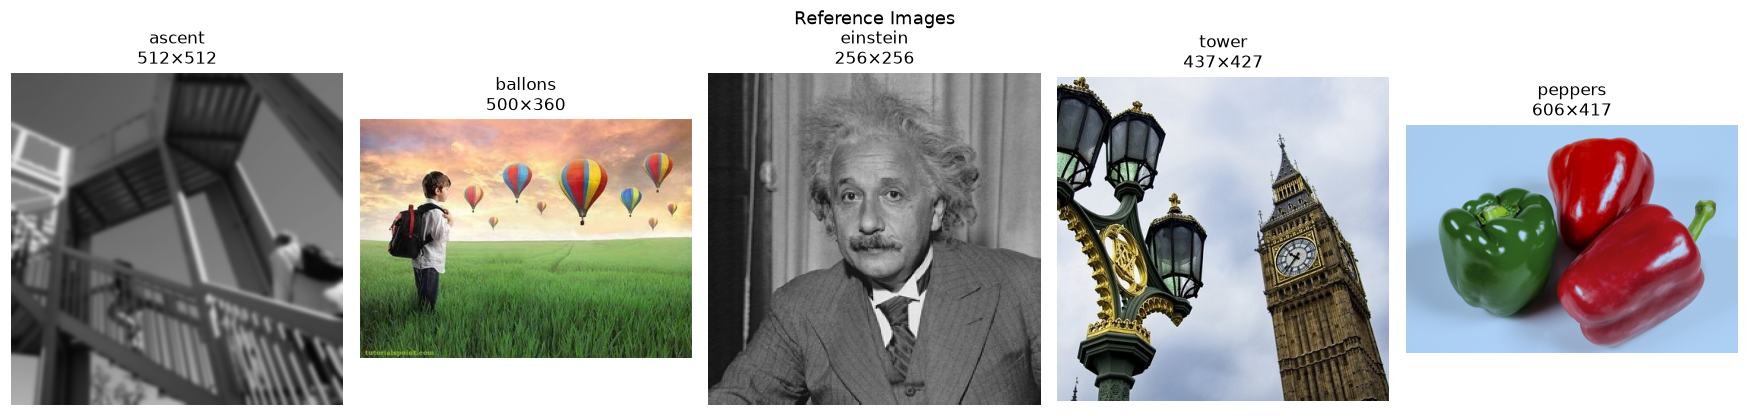

In [4]:
fig, axes = plt.subplots(1, len(images_rgb), figsize=(16, 4))

for ax, (name, image) in zip(axes, images_rgb.items()):
    ax.imshow(image)
    ax.set_title(f"{name}\n{image.shape[1]}×{image.shape[0]}")
    ax.axis("off")

fig.suptitle("Reference Images")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_reference_images.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. What Is an Intensity Transformation?

An intensity transformation changes pixel **values** but does not move pixels.

For a grayscale image:

$$
s = T(r)
$$

where:

- $r$ = input intensity;
- $T$ = transformation function;
- $s$ = output intensity.

The transformation is **pointwise** when each output pixel depends only on the corresponding input pixel:

$$
J(y,x)=T(I(y,x))
$$

The spatial coordinates remain unchanged.

### 3.1 Identity Transformation

The simplest transformation is:

$$
s=r
$$

Nothing changes.

Identity is useful as a reference because every other transformation can be compared with it.

In [5]:
ascent = images_gray["ascent"]

identity = ascent.copy()

assert np.array_equal(identity, ascent)

print("Identity transformation preserves every pixel:", np.array_equal(identity, ascent))

Identity transformation preserves every pixel: True


## 4. Image Negative

For an 8-bit grayscale image:

$$
s = 255-r
$$

Dark intensities become bright and bright intensities become dark.

The operation reverses the gray scale but preserves spatial structure.

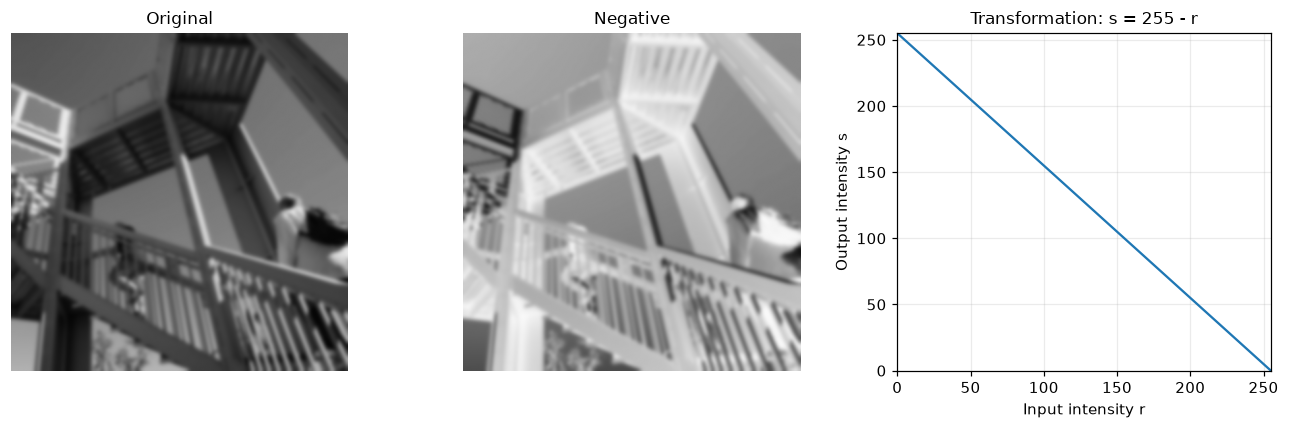

In [6]:
negative = 255 - ascent

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(ascent, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(negative, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Negative")

axes[2].plot(np.arange(256), 255 - np.arange(256))
axes[2].set_title("Transformation: s = 255 - r")
axes[2].set_xlabel("Input intensity r")
axes[2].set_ylabel("Output intensity s")
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].grid(alpha=0.25)

for ax in axes[:2]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_negative.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

A negative does not add new information. It changes the intensity representation.

Negative images can make some structures easier to perceive when bright details are embedded in predominantly dark regions or vice versa.

## 5. Brightness and Contrast

A simple linear point transformation is:

$$
s = ar+b
$$

where:

- $a$ controls contrast;
- $b$ controls brightness.

Typical cases:

```text
a = 1, b > 0  → brighter
a = 1, b < 0  → darker
a > 1          → stronger contrast around zero
0 < a < 1      → compressed contrast
```

Because an 8-bit image can store only 0–255, the result must be clipped.

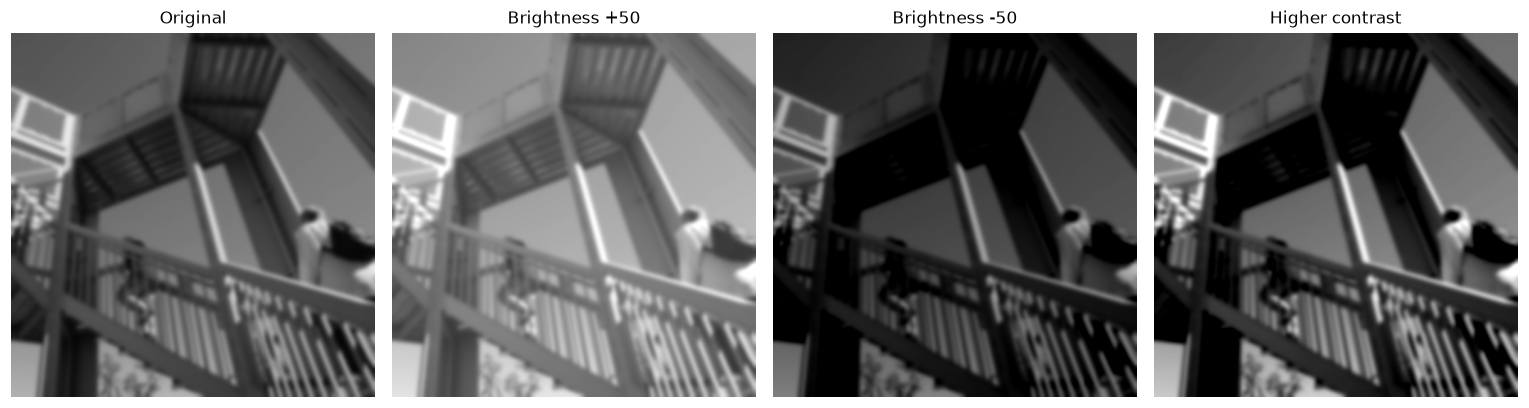

In [7]:
def linear_intensity_transform(
    image: np.ndarray,
    gain: float = 1.0,
    offset: float = 0.0,
) -> np.ndarray:
    """Apply s = gain*r + offset safely to a uint8 image."""
    transformed = gain * image.astype(np.float32) + offset
    return np.clip(transformed, 0, 255).astype(np.uint8)


brighter = linear_intensity_transform(ascent, gain=1.0, offset=50)
darker = linear_intensity_transform(ascent, gain=1.0, offset=-50)
higher_contrast = linear_intensity_transform(ascent, gain=1.5, offset=-64)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

examples = [
    ("Original", ascent),
    ("Brightness +50", brighter),
    ("Brightness -50", darker),
    ("Higher contrast", higher_contrast),
]

for ax, (title, image) in zip(axes, examples):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_brightness_contrast.png", dpi=300, bbox_inches="tight")
plt.show()

### Common pitfall — clipping

If a transformation produces a value below 0 or above 255, it cannot be represented as an 8-bit intensity.

Safe workflow:

```text
uint8
  ↓
convert to float
  ↓
transform
  ↓
clip to [0, 255]
  ↓
convert back to uint8
```

Direct unsigned-integer arithmetic can wrap around and produce incorrect values.

## 6. Contrast Stretching

A low-contrast image uses only a narrow part of the available intensity range.

Min-max contrast stretching maps:

$$
r_{\min}\rightarrow 0
$$

and:

$$
r_{\max}\rightarrow 255
$$

using:

$$
s=
\frac{r-r_{\min}}
{r_{\max}-r_{\min}}
\times255
$$

This is a global linear transformation.

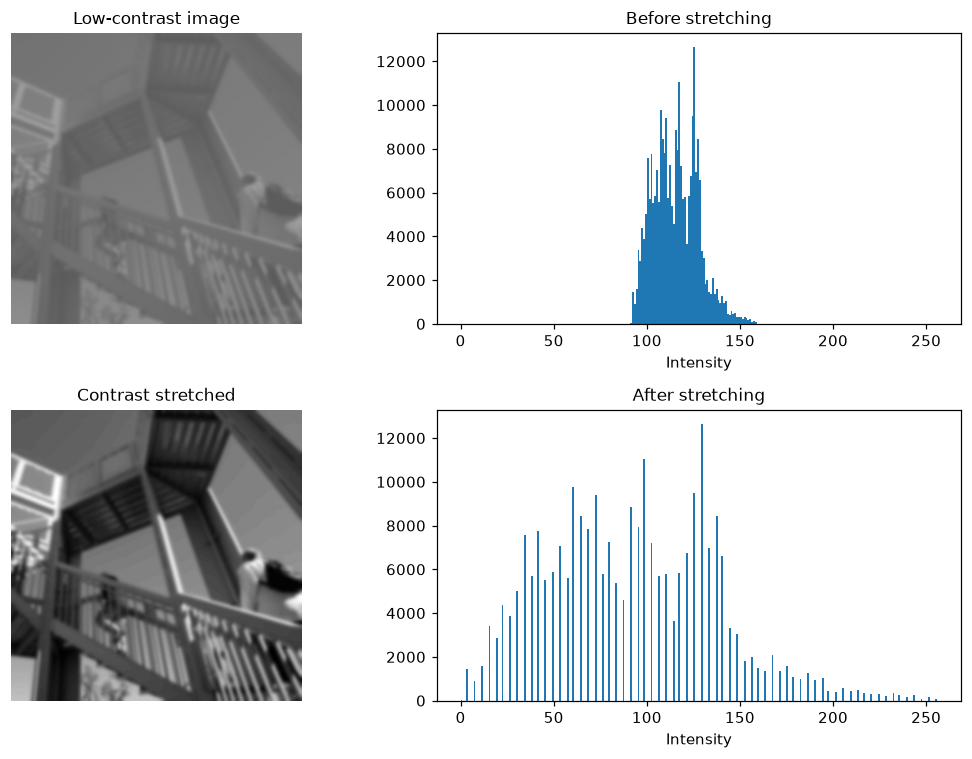

Before: 91 to 158
After : 0 to 255


In [8]:
def contrast_stretch(image: np.ndarray) -> np.ndarray:
    """Stretch the observed intensity range to [0, 255]."""
    image_f = image.astype(np.float32)
    r_min = image_f.min()
    r_max = image_f.max()

    if r_max == r_min:
        return np.zeros_like(image)

    stretched = (image_f - r_min) / (r_max - r_min)
    stretched *= 255.0

    return np.clip(stretched, 0, 255).astype(np.uint8)


# Create a controlled low-contrast version for demonstration.
low_contrast = 90 + (ascent.astype(np.float32) / 255.0) * 75
low_contrast = np.clip(low_contrast, 0, 255).astype(np.uint8)

stretched = contrast_stretch(low_contrast)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].imshow(low_contrast, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Low-contrast image")
axes[0, 0].axis("off")

axes[0, 1].hist(low_contrast.ravel(), bins=256, range=(0, 256))
axes[0, 1].set_title("Before stretching")
axes[0, 1].set_xlabel("Intensity")

axes[1, 0].imshow(stretched, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Contrast stretched")
axes[1, 0].axis("off")

axes[1, 1].hist(stretched.ravel(), bins=256, range=(0, 256))
axes[1, 1].set_title("After stretching")
axes[1, 1].set_xlabel("Intensity")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_contrast_stretching.png", dpi=300, bbox_inches="tight")
plt.show()

print("Before:", int(low_contrast.min()), "to", int(low_contrast.max()))
print("After :", int(stretched.min()), "to", int(stretched.max()))

### Important distinction

Contrast stretching uses only the minimum and maximum intensity values.

Histogram equalization, introduced later, uses the **entire intensity distribution**.

## 7. Logarithmic Transformation

The log transform is:

$$
s=c\log(1+r)
$$

The logarithm expands small input values and compresses large values.

This can reveal information stored in dark intensity regions while compressing a large dynamic range.

For an 8-bit output, $c$ is chosen so the maximum maps to 255.

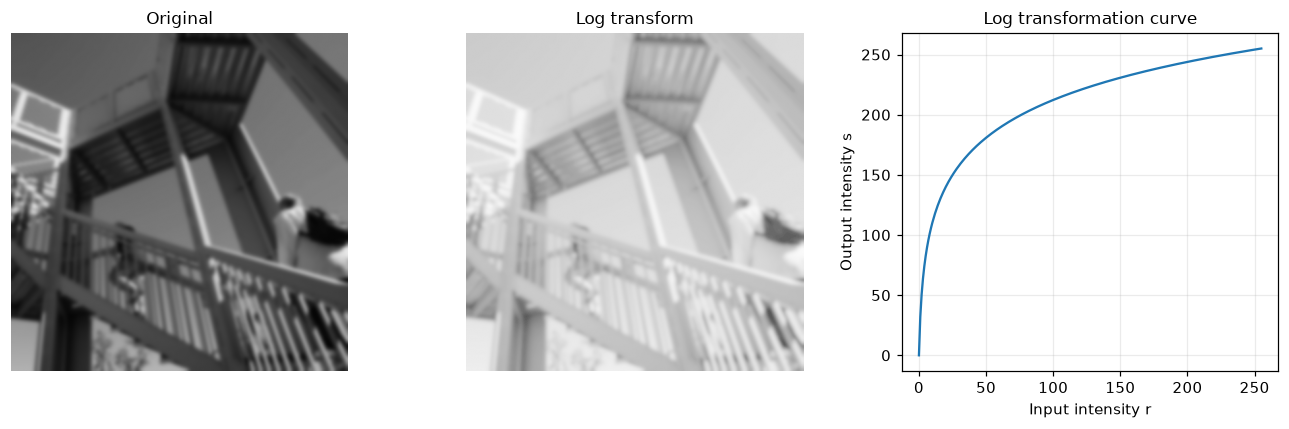

In [9]:
def log_transform(image: np.ndarray) -> np.ndarray:
    """Apply an 8-bit logarithmic intensity transformation."""
    image_f = image.astype(np.float32)

    c = 255.0 / np.log1p(255.0)
    transformed = c * np.log1p(image_f)

    return np.clip(transformed, 0, 255).astype(np.uint8)


logged = log_transform(ascent)

r = np.arange(256, dtype=np.float32)
log_curve = (255.0 / np.log1p(255.0)) * np.log1p(r)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(ascent, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(logged, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Log transform")
axes[1].axis("off")

axes[2].plot(r, log_curve)
axes[2].set_title("Log transformation curve")
axes[2].set_xlabel("Input intensity r")
axes[2].set_ylabel("Output intensity s")
axes[2].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_log_transform.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The log curve is steep near low intensities and flatter at high intensities.

Therefore:

- dark values are separated more strongly;
- large bright values are compressed.

Log transformation is commonly useful when data contain a very large dynamic range.

## 8. Gamma / Power-Law Transformation

The normalized power-law transformation is:

$$
s=r^\gamma
$$

where $r$ and $s$ are normalized to $[0,1]$.

General behavior:

- $\gamma<1$ → brightens many mid/dark values;
- $\gamma=1$ → identity;
- $\gamma>1$ → darkens many mid values.

This is closely related to gamma correction used in imaging and display systems.

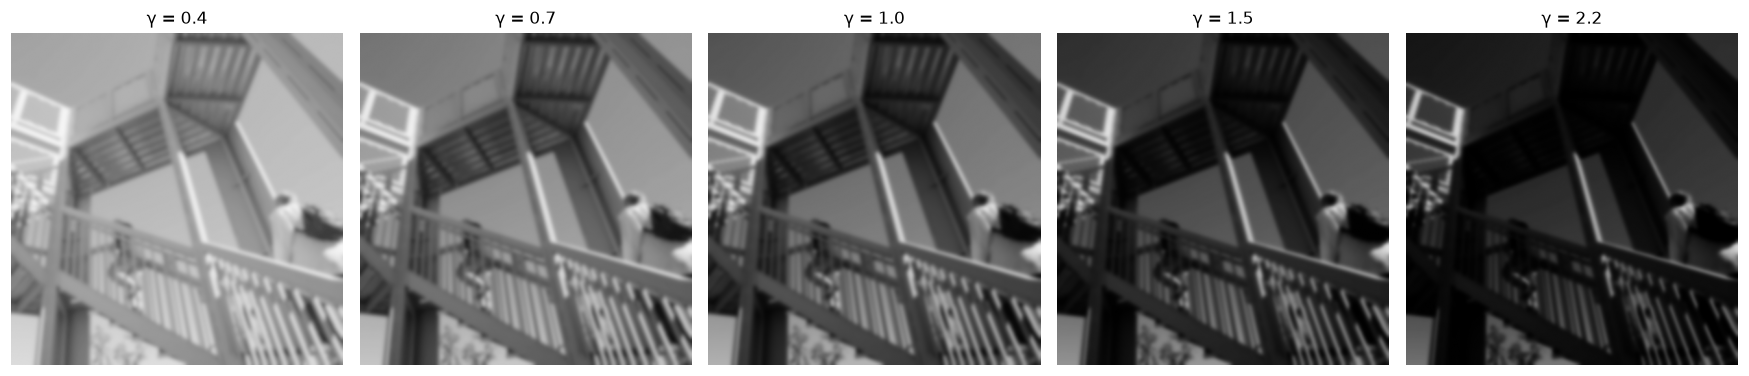

In [10]:
def gamma_transform(image: np.ndarray, gamma: float) -> np.ndarray:
    """Apply normalized power-law transformation s = r**gamma."""
    if gamma <= 0:
        raise ValueError("gamma must be strictly positive.")

    normalized = image.astype(np.float32) / 255.0
    transformed = normalized ** gamma

    return np.clip(transformed * 255.0, 0, 255).astype(np.uint8)


gammas = [0.4, 0.7, 1.0, 1.5, 2.2]

fig, axes = plt.subplots(1, len(gammas), figsize=(16, 3.6))

for ax, gamma in zip(axes, gammas):
    transformed = gamma_transform(ascent, gamma)
    ax.imshow(transformed, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"γ = {gamma}")
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_gamma_examples.png", dpi=300, bbox_inches="tight")
plt.show()

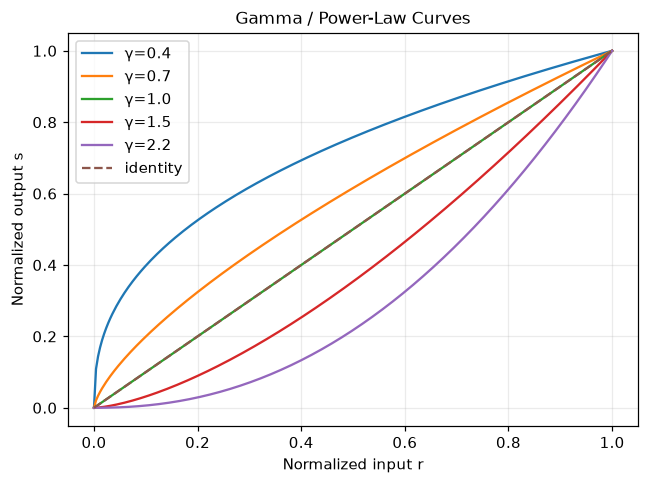

In [11]:
r = np.linspace(0, 1, 256)

fig, ax = plt.subplots(figsize=(6, 4.5))

for gamma in gammas:
    ax.plot(r, r ** gamma, label=f"γ={gamma}")

ax.plot(r, r, linestyle="--", label="identity")
ax.set_title("Gamma / Power-Law Curves")
ax.set_xlabel("Normalized input r")
ax.set_ylabel("Normalized output s")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_gamma_curves.png", dpi=300, bbox_inches="tight")
plt.show()

### Common pitfall

Gamma values must be interpreted together with the chosen formula.

This notebook uses:

$$
s=r^\gamma
$$

Some software or display standards describe the inverse exponent instead. Always verify the exact convention.

## 9. Histogram Equalization

Histogram equalization is a global intensity transformation derived from the image histogram.

For an 8-bit image:

1. compute the histogram;
2. normalize it to obtain a probability distribution;
3. compute the cumulative distribution function (CDF);
4. map each input intensity through the CDF.

Conceptually:

$$
s=(L-1)\,\mathrm{CDF}(r)
$$

with $L=256$.

Unlike contrast stretching, the transform depends on the whole intensity distribution.

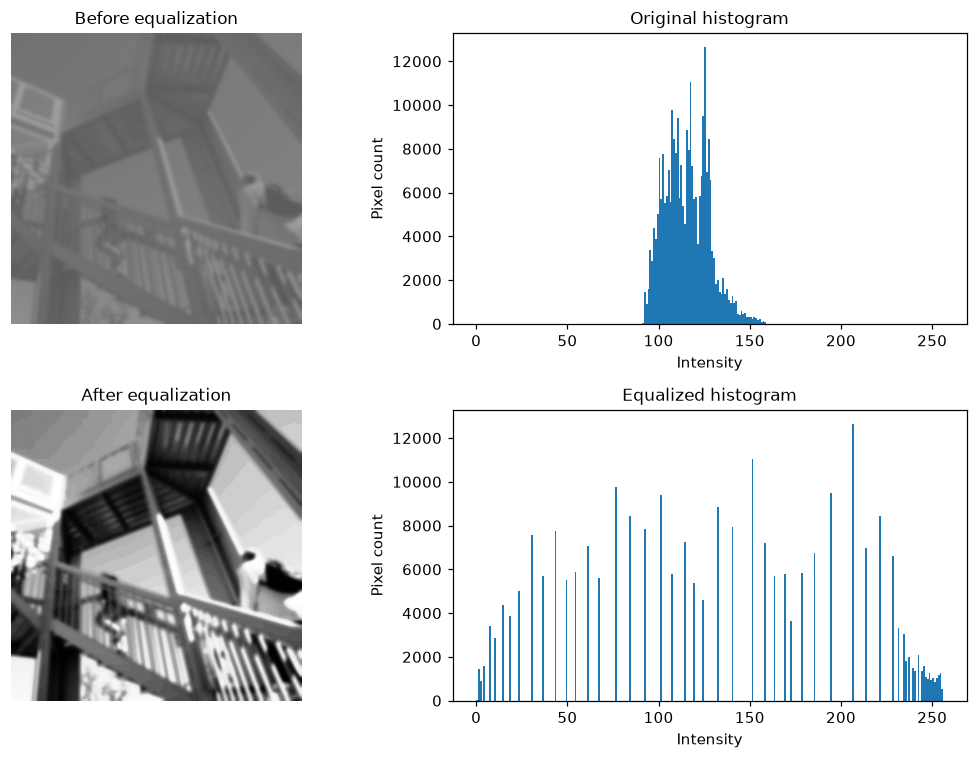

In [12]:
def histogram_equalize(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Equalize an 8-bit grayscale image using its cumulative histogram."""
    histogram = np.bincount(image.ravel(), minlength=256)

    probability = histogram / image.size
    cdf = np.cumsum(probability)

    # Map the CDF to the 8-bit range.
    mapping = np.round(255 * cdf).astype(np.uint8)
    equalized = mapping[image]

    return equalized, mapping


equalized, equalization_map = histogram_equalize(low_contrast)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].imshow(low_contrast, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Before equalization")
axes[0, 0].axis("off")

axes[0, 1].hist(low_contrast.ravel(), bins=256, range=(0, 256))
axes[0, 1].set_title("Original histogram")

axes[1, 0].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("After equalization")
axes[1, 0].axis("off")

axes[1, 1].hist(equalized.ravel(), bins=256, range=(0, 256))
axes[1, 1].set_title("Equalized histogram")

for ax in [axes[0, 1], axes[1, 1]]:
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Pixel count")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_histogram_equalization.png", dpi=300, bbox_inches="tight")
plt.show()

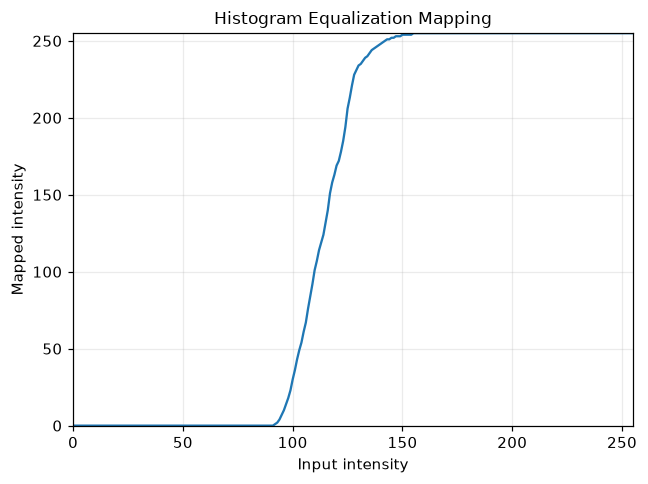

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(np.arange(256), equalization_map)
ax.set_title("Histogram Equalization Mapping")
ax.set_xlabel("Input intensity")
ax.set_ylabel("Mapped intensity")
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_equalization_mapping.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation and limitation

Histogram equalization can improve global contrast, but it is not automatically the best result for every image.

Because it is global:

- local regions may still have weak contrast;
- noise may become more visible;
- brightness appearance can change.

Adaptive histogram methods belong to more advanced enhancement workflows.

## 10. Compare the Fundamental Intensity Transformations

The following comparison emphasizes an important idea:

**every transformation changes the histogram differently while preserving pixel locations.**

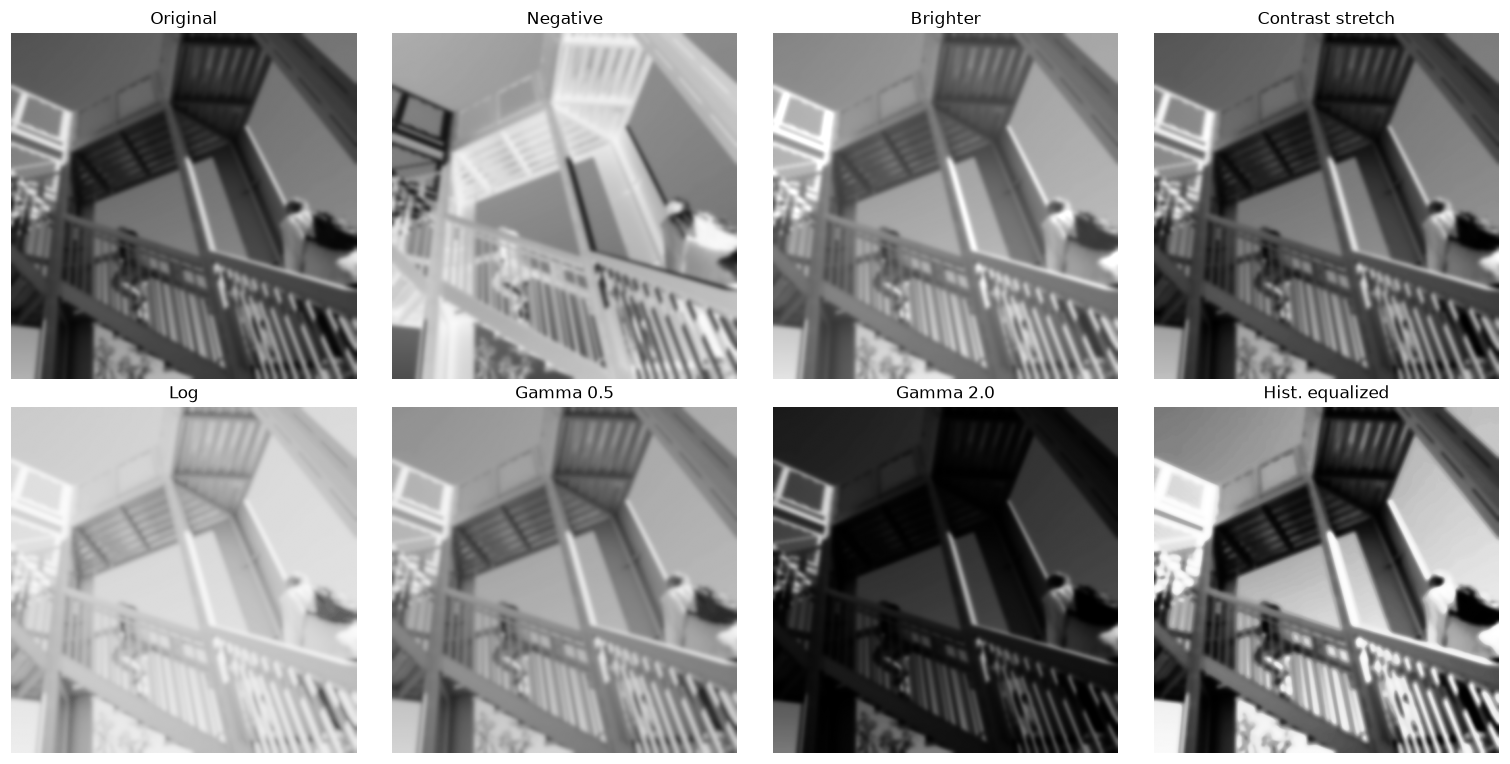

In [14]:
comparison = [
    ("Original", ascent),
    ("Negative", negative),
    ("Brighter", brighter),
    ("Contrast stretch", contrast_stretch(ascent)),
    ("Log", logged),
    ("Gamma 0.5", gamma_transform(ascent, 0.5)),
    ("Gamma 2.0", gamma_transform(ascent, 2.0)),
    ("Hist. equalized", histogram_equalize(ascent)[0]),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (title, image) in zip(axes.ravel(), comparison):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "10_intensity_transform_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 11. What Is a Geometric Transformation?

A geometric transformation changes **where image content is located**.

Instead of changing intensity $r\rightarrow s$, we transform coordinates:

$$
(x,y)\rightarrow(x',y')
$$

Examples include:

- translation;
- scaling;
- rotation;
- reflection;
- shear.

After the coordinate transformation, the output grid usually asks for values at locations that do not correspond exactly to integer input pixels. This is why **interpolation** becomes necessary.

## 12. Homogeneous Coordinates

A 2-D point:

$$
(x,y)
$$

is represented in homogeneous form as:

$$
\mathbf{p}
=
\begin{bmatrix}
x\\
y\\
1
\end{bmatrix}
$$

This allows translation, rotation, scaling, reflection, shear, and affine transformations to be written using matrix multiplication:

$$
\mathbf{p}'=\mathbf{H}\mathbf{p}
$$

where $\mathbf{H}$ is a $3\times3$ transformation matrix.

In [15]:
def apply_to_point(matrix: np.ndarray, x: float, y: float) -> np.ndarray:
    """Apply a 3x3 homogeneous transform to one 2-D point."""
    point = np.array([x, y, 1.0], dtype=np.float64)
    transformed = matrix @ point
    return transformed[:2] / transformed[2]


identity_matrix = np.eye(3)

print("Identity matrix:")
print(identity_matrix)
print("Point (10, 20) ->", apply_to_point(identity_matrix, 10, 20))

Identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Point (10, 20) -> [10. 20.]


## 13. Fundamental Geometric Transformation Matrices

### Translation

$$
\mathbf{T}
=
\begin{bmatrix}
1&0&t_x\\
0&1&t_y\\
0&0&1
\end{bmatrix}
$$

### Scaling

$$
\mathbf{S}
=
\begin{bmatrix}
s_x&0&0\\
0&s_y&0\\
0&0&1
\end{bmatrix}
$$

### Rotation about the origin

$$
\mathbf{R}
=
\begin{bmatrix}
\cos\theta&-\sin\theta&0\\
\sin\theta&\cos\theta&0\\
0&0&1
\end{bmatrix}
$$

### Horizontal shear

$$
\mathbf{H}_x
=
\begin{bmatrix}
1&k_x&0\\
0&1&0\\
0&0&1
\end{bmatrix}
$$

### Reflection about the vertical axis

$$
\mathbf{F}_x
=
\begin{bmatrix}
-1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix}
$$

The image coordinate system has $y$ increasing downward, so visual rotation direction must be interpreted carefully.

In [16]:
def translation_matrix(tx: float, ty: float) -> np.ndarray:
    return np.array(
        [[1.0, 0.0, tx],
         [0.0, 1.0, ty],
         [0.0, 0.0, 1.0]]
    )


def scaling_matrix(sx: float, sy: float) -> np.ndarray:
    return np.array(
        [[sx, 0.0, 0.0],
         [0.0, sy, 0.0],
         [0.0, 0.0, 1.0]]
    )


def rotation_matrix(angle_degrees: float) -> np.ndarray:
    angle = np.deg2rad(angle_degrees)
    c = np.cos(angle)
    s = np.sin(angle)

    return np.array(
        [[c, -s, 0.0],
         [s,  c, 0.0],
         [0.0, 0.0, 1.0]]
    )


def shear_matrix(kx: float = 0.0, ky: float = 0.0) -> np.ndarray:
    return np.array(
        [[1.0, kx, 0.0],
         [ky, 1.0, 0.0],
         [0.0, 0.0, 1.0]]
    )


def horizontal_reflection_matrix() -> np.ndarray:
    return np.array(
        [[-1.0, 0.0, 0.0],
         [0.0, 1.0, 0.0],
         [0.0, 0.0, 1.0]]
    )

## 14. The Origin and the Image Center

Scaling and rotation matrices naturally operate around the coordinate origin `(0, 0)`.

For images, `(0, 0)` is normally the top-left corner.

To rotate or scale around the image center:

```text
1. translate the center to the origin
2. apply the transformation
3. translate back
```

In homogeneous matrices:

```text
H_centered = T(center) @ H @ T(-center)
```

In [17]:
def around_center(
    matrix: np.ndarray,
    image_shape: tuple[int, ...],
) -> np.ndarray:
    """Move a geometric transformation so it acts around the image center."""
    height, width = image_shape[:2]

    cx = (width - 1) / 2.0
    cy = (height - 1) / 2.0

    to_origin = translation_matrix(-cx, -cy)
    back = translation_matrix(cx, cy)

    return back @ matrix @ to_origin

## 15. Forward Mapping vs Inverse Mapping

Suppose the forward transform is:

$$
\mathbf{p}_{out}
=
\mathbf{H}\mathbf{p}_{in}
$$

A tempting implementation is to send every input pixel to its transformed output position.

This is **forward mapping**.

The problem is that discrete transformed coordinates can leave holes in the output.

Image warping normally uses **inverse mapping**:

$$
\mathbf{p}_{in}
=
\mathbf{H}^{-1}\mathbf{p}_{out}
$$

For every output pixel:

1. ask where it came from in the input;
2. sample the input image at that location;
3. interpolate if the location is non-integer.

### Interpolation order used in this notebook

SciPy interpolation orders:

```text
0 → nearest neighbor
1 → bilinear
3 → bicubic
```

In [18]:
def warp_affine(
    image: np.ndarray,
    forward_matrix: np.ndarray,
    output_shape: tuple[int, int] | None = None,
    interpolation_order: int = 1,
    fill_value: float = 0.0,
) -> np.ndarray:
    """Warp an image with inverse mapping from a forward 3x3 affine matrix."""

    if output_shape is None:
        output_shape = image.shape[:2]

    out_h, out_w = output_shape

    # Build every integer output coordinate (x_out, y_out).
    yy, xx = np.indices((out_h, out_w), dtype=np.float64)
    homogeneous_output = np.stack(
        [xx.ravel(), yy.ravel(), np.ones(xx.size)],
        axis=0,
    )

    # Inverse mapping: output coordinate -> source coordinate.
    inverse_matrix = np.linalg.inv(forward_matrix)
    homogeneous_input = inverse_matrix @ homogeneous_output

    x_in = homogeneous_input[0]
    y_in = homogeneous_input[1]

    coordinates = np.vstack([y_in, x_in])

    if image.ndim == 2:
        warped = map_coordinates(
            image.astype(np.float32),
            coordinates,
            order=interpolation_order,
            mode="constant",
            cval=fill_value,
        ).reshape(out_h, out_w)

    elif image.ndim == 3:
        channels = []
        for channel_index in range(image.shape[2]):
            sampled = map_coordinates(
                image[..., channel_index].astype(np.float32),
                coordinates,
                order=interpolation_order,
                mode="constant",
                cval=fill_value,
            ).reshape(out_h, out_w)
            channels.append(sampled)

        warped = np.stack(channels, axis=-1)

    else:
        raise ValueError("Expected a 2-D grayscale or 3-D color image.")

    return np.clip(warped, 0, 255).astype(np.uint8)

## 16. Translation

Translation moves every point by the same displacement:

```text
x' = x + tx
y' = y + ty
```

Important consequences:

- output pixels can leave the image canvas;
- newly uncovered regions need a fill value;
- image dimensions do not have to change.

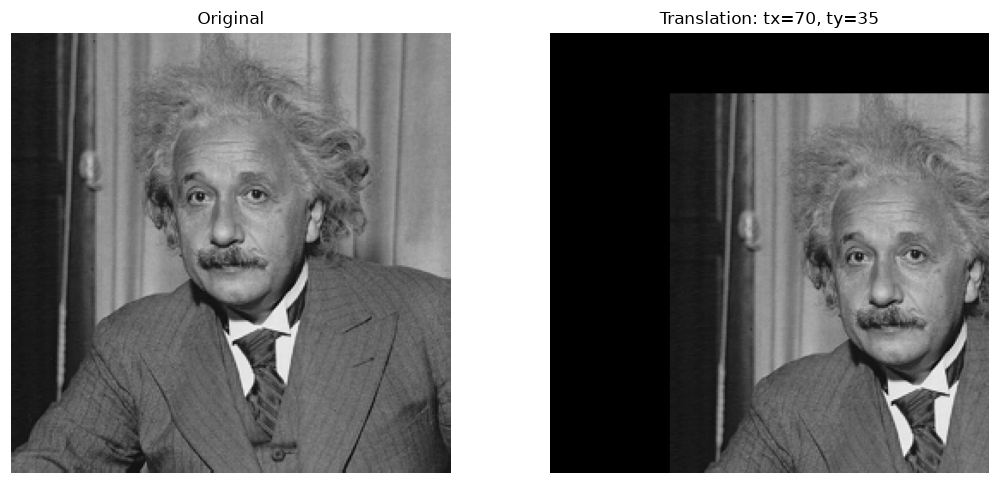

In [19]:
einstein = images_gray["einstein"]

T = translation_matrix(tx=70, ty=35)
translated = warp_affine(
    einstein,
    T,
    interpolation_order=0,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].imshow(einstein, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(translated, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Translation: tx=70, ty=35")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_translation.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Rotation

Rotation changes orientation.

The standard rotation matrix acts around the origin. For an image, rotating around the center is usually more intuitive.

Because the image $y$-axis points downward, the visual direction associated with the mathematical sign of $\theta$ can appear reversed compared with a standard Cartesian graph.

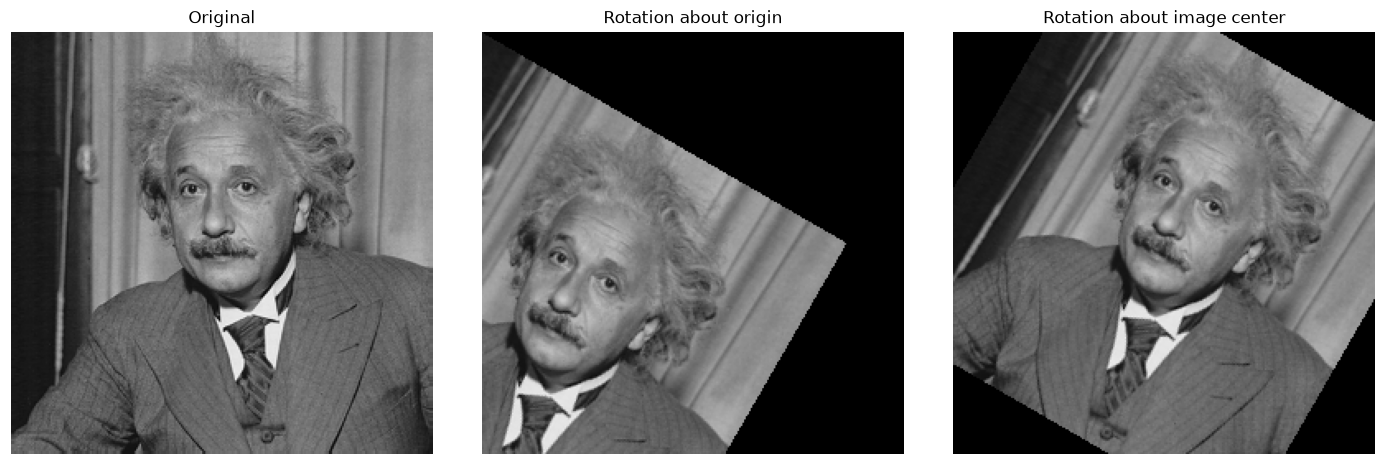

In [20]:
R_origin = rotation_matrix(30)
R_center = around_center(rotation_matrix(30), einstein.shape)

rotated_origin = warp_affine(einstein, R_origin, interpolation_order=1)
rotated_center = warp_affine(einstein, R_center, interpolation_order=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

axes[0].imshow(einstein, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(rotated_origin, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Rotation about origin")

axes[2].imshow(rotated_center, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Rotation about image center")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "12_rotation_origin_center.png", dpi=300, bbox_inches="tight")
plt.show()

### Why does rotation crop the image?

The output canvas in the example keeps the same width and height as the input.

After rotation, some transformed content lies outside that fixed rectangle and is therefore not represented.

A larger output canvas can preserve more content, but requires computing transformed corner bounds and a new translation.

## 18. Scaling and Resizing

Scaling changes the spatial size of image content.

Uniform scaling uses:

```text
sx = sy
```

and preserves shape proportions.

Non-uniform scaling uses:

```text
sx ≠ sy
```

and changes the aspect ratio of the content.

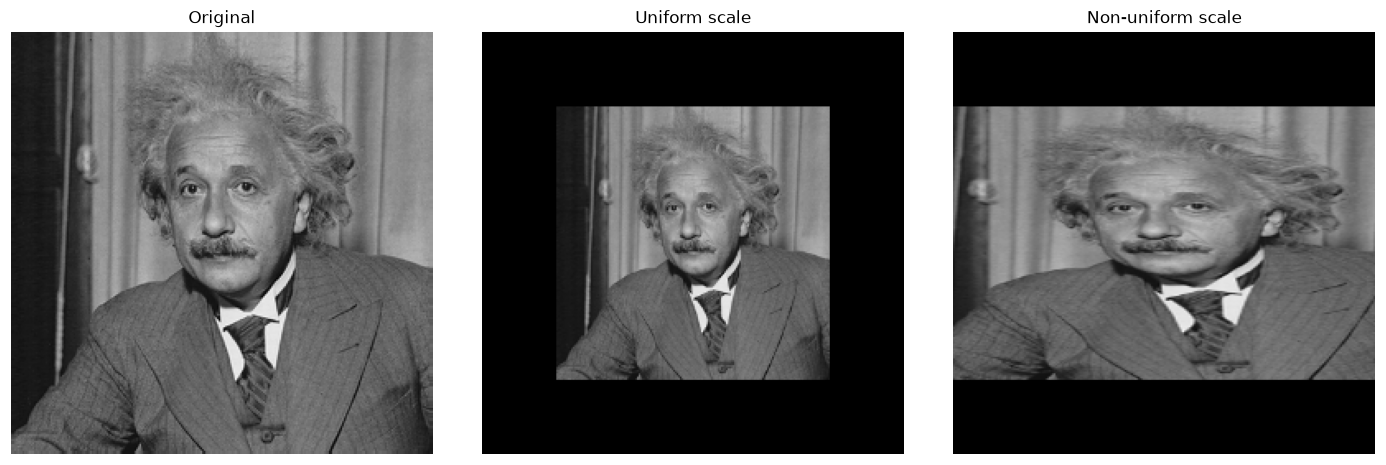

In [21]:
S_uniform = around_center(
    scaling_matrix(0.65, 0.65),
    einstein.shape,
)

S_nonuniform = around_center(
    scaling_matrix(1.35, 0.65),
    einstein.shape,
)

scaled_uniform = warp_affine(
    einstein,
    S_uniform,
    interpolation_order=1,
)

scaled_nonuniform = warp_affine(
    einstein,
    S_nonuniform,
    interpolation_order=1,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

axes[0].imshow(einstein, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(scaled_uniform, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Uniform scale")

axes[2].imshow(scaled_nonuniform, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Non-uniform scale")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "13_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

### Aspect ratio

For an image:

$$
\text{aspect ratio}=
\frac{\text{width}}{\text{height}}
$$

If width and height are scaled by different factors, object proportions are distorted.

Preserving aspect ratio is usually desirable unless deliberate deformation is intended.

## 19. Why Interpolation Is Necessary

A geometric transform often asks for the input intensity at a coordinate such as:

```text
x = 104.37
y = 83.62
```

But digital images only store samples at integer coordinates.

Interpolation estimates a value between known pixels.

### Nearest neighbor

Uses the closest pixel.

- fastest;
- preserves discrete labels;
- can look blocky.

### Bilinear

Uses the four nearest spatial samples.

- smoother;
- common for ordinary image resizing and warping.

### Bicubic

Uses a larger neighborhood and a cubic model.

- often smoother/sharper;
- more computationally expensive;
- can introduce overshoot before clipping.

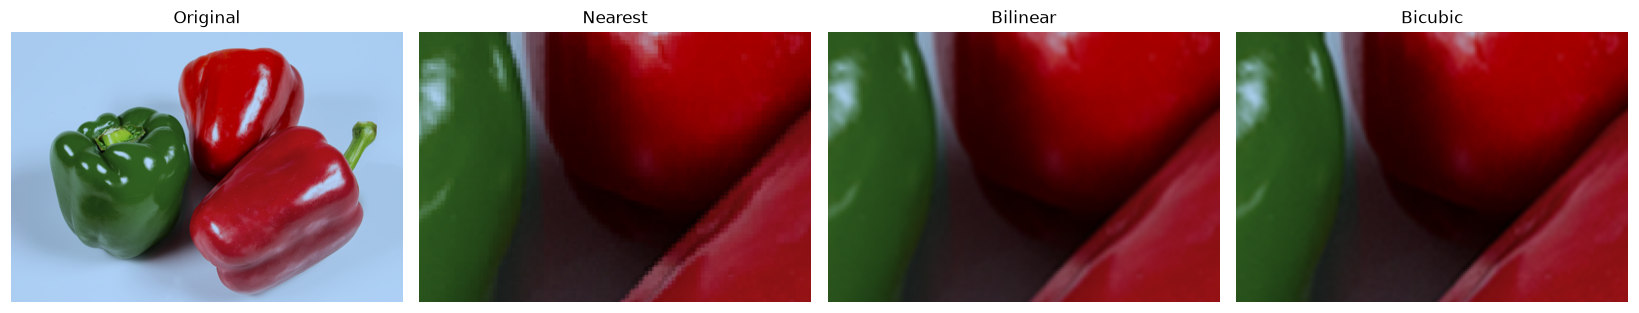

In [22]:
peppers_rgb = images_rgb["peppers"]

scale_for_interpolation = around_center(
    scaling_matrix(1.7, 1.7),
    peppers_rgb.shape,
)

nearest = warp_affine(
    peppers_rgb,
    scale_for_interpolation,
    interpolation_order=0,
)
bilinear = warp_affine(
    peppers_rgb,
    scale_for_interpolation,
    interpolation_order=1,
)
bicubic = warp_affine(
    peppers_rgb,
    scale_for_interpolation,
    interpolation_order=3,
)

# Crop the same central region to make interpolation differences easier to inspect.
h, w = peppers_rgb.shape[:2]
crop = (
    slice(h // 3, 2 * h // 3),
    slice(w // 3, 2 * w // 3),
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(peppers_rgb)
axes[0].set_title("Original")

axes[1].imshow(nearest[crop])
axes[1].set_title("Nearest")

axes[2].imshow(bilinear[crop])
axes[2].set_title("Bilinear")

axes[3].imshow(bicubic[crop])
axes[3].set_title("Bicubic")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "14_interpolation_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Choosing interpolation

A practical rule:

| Data type | Typical choice |
|---|---|
| Natural photograph | bilinear or bicubic |
| Binary mask | nearest |
| Class-label image | nearest |
| Continuous-valued intensity image | bilinear / bicubic |

Using bilinear interpolation on a class-label mask can create invalid intermediate labels.

## 20. Reflection / Flipping

A horizontal reflection changes left-right orientation.

The pure reflection matrix acts around the origin, so it must be translated appropriately to remain inside the image canvas.

For width $W$:

```text
x' = (W - 1) - x
```

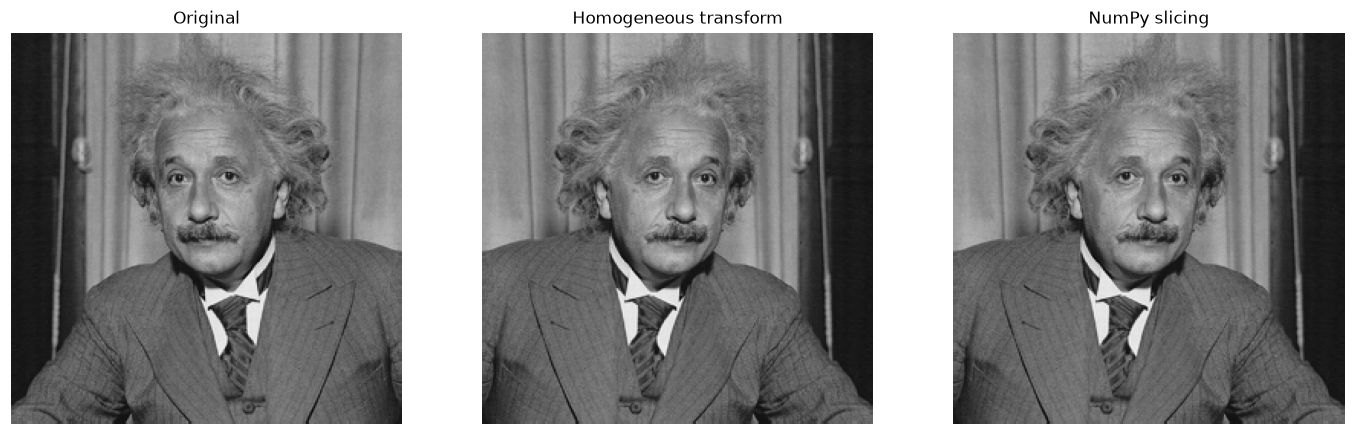

Two reflection methods identical: True


In [23]:
height, width = einstein.shape

F = translation_matrix(width - 1, 0) @ horizontal_reflection_matrix()
reflected = warp_affine(einstein, F, interpolation_order=0)

# NumPy provides the same left-right operation directly.
reflected_numpy = einstein[:, ::-1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(einstein, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(reflected, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Homogeneous transform")

axes[2].imshow(reflected_numpy, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("NumPy slicing")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "15_reflection.png", dpi=300, bbox_inches="tight")
plt.show()

print("Two reflection methods identical:", np.array_equal(reflected, reflected_numpy))

## 21. Shear

Shearing slants an image.

Horizontal shear:

```text
x' = x + kx*y
y' = y
```

Vertical shear:

```text
x' = x
y' = ky*x + y
```

Shear preserves straight lines but changes angles and shape.

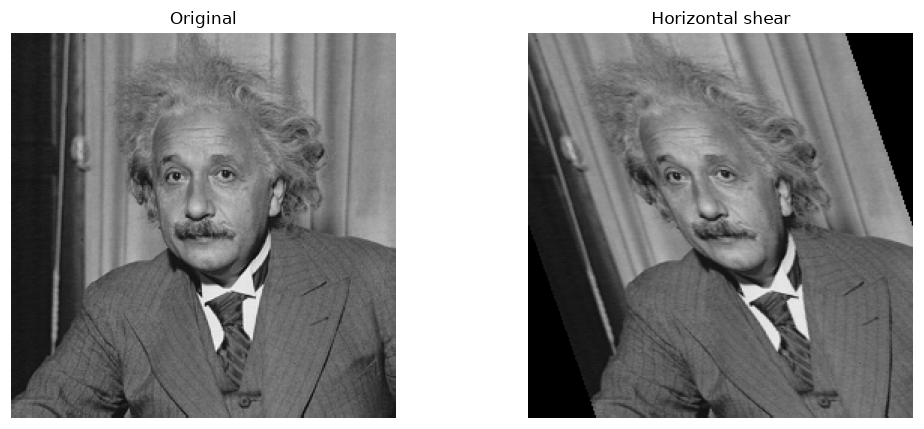

In [24]:
shear_centered = around_center(
    shear_matrix(kx=0.35, ky=0.0),
    einstein.shape,
)

sheared = warp_affine(
    einstein,
    shear_centered,
    interpolation_order=1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(einstein, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(sheared, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Horizontal shear")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "16_shear.png", dpi=300, bbox_inches="tight")
plt.show()

## 22. Composition of Transformations

Several geometric transformations can be combined into one matrix.

If:

$$
\mathbf{p}'=
\mathbf{H}_2\mathbf{H}_1\mathbf{p}
$$

then $\mathbf{H}_1$ acts **first** and $\mathbf{H}_2$ acts **second**.

Matrix multiplication is not commutative:

$$
\mathbf{H}_2\mathbf{H}_1
\neq
\mathbf{H}_1\mathbf{H}_2
$$

Therefore, transformation order matters.

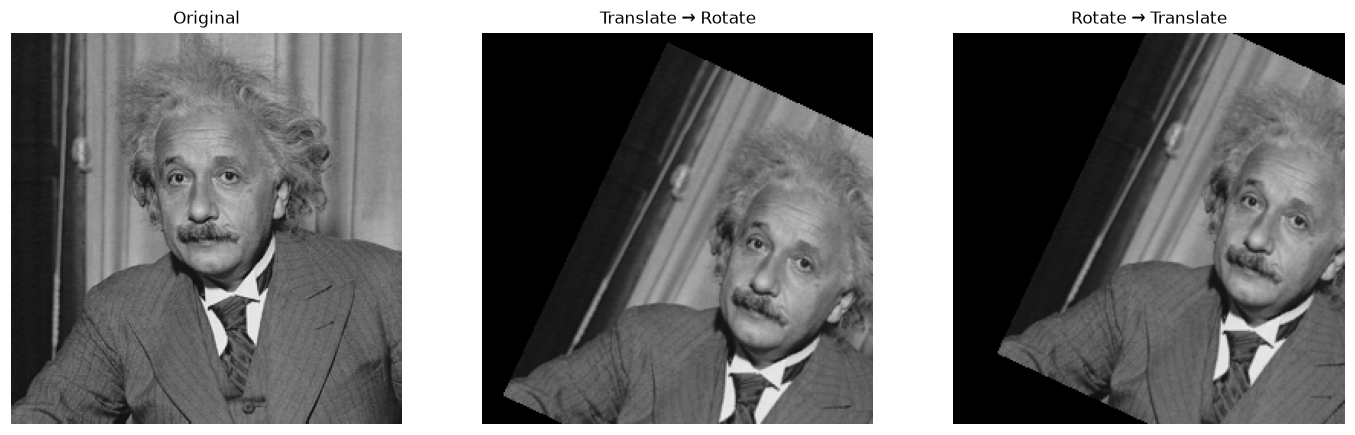

In [25]:
# Two transformations applied in opposite orders.
translate = translation_matrix(70, 20)
rotate = around_center(rotation_matrix(25), einstein.shape)

translate_then_rotate = rotate @ translate
rotate_then_translate = translate @ rotate

image_a = warp_affine(
    einstein,
    translate_then_rotate,
    interpolation_order=1,
)

image_b = warp_affine(
    einstein,
    rotate_then_translate,
    interpolation_order=1,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(einstein, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(image_a, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Translate → Rotate")

axes[2].imshow(image_b, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Rotate → Translate")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "17_transformation_order.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 23. General Affine Transformation

An affine transformation has the form:

$$
\begin{bmatrix}
x'\\
y'\\
1
\end{bmatrix}
=
\begin{bmatrix}
a&b&t_x\\
c&d&t_y\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
x\\
y\\
1
\end{bmatrix}
$$

Affine transformations can combine:

- translation;
- rotation;
- scaling;
- reflection;
- shear.

A key geometric property is that **parallel lines remain parallel**.

Perspective effects are not represented by a general affine transform; they require a projective homography.

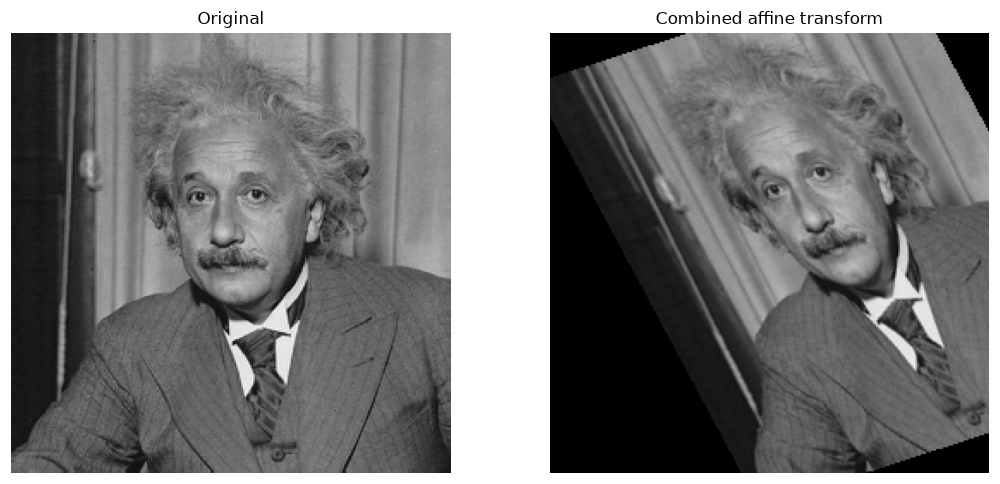

In [26]:
affine = (
    translation_matrix(35, -10)
    @ around_center(rotation_matrix(-18), einstein.shape)
    @ around_center(shear_matrix(kx=0.18), einstein.shape)
    @ around_center(scaling_matrix(0.88, 1.08), einstein.shape)
)

affine_result = warp_affine(
    images_rgb["einstein"],
    affine,
    interpolation_order=1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].imshow(images_rgb["einstein"])
axes[0].set_title("Original")

axes[1].imshow(affine_result)
axes[1].set_title("Combined affine transform")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "18_affine_transform.png", dpi=300, bbox_inches="tight")
plt.show()

## 24. Resizing to a New Array Shape

So far, the warp examples kept a fixed canvas.

In real workflows, resizing often means creating an output array with a different shape.

Pillow provides explicit resampling methods for this purpose.

In [27]:
source = Image.fromarray(images_rgb["peppers"])

original_width, original_height = source.size

new_width = original_width // 2
new_height = original_height // 2

resized_nearest = np.asarray(
    source.resize(
        (new_width, new_height),
        resample=Image.Resampling.NEAREST,
    )
)

resized_bilinear = np.asarray(
    source.resize(
        (new_width, new_height),
        resample=Image.Resampling.BILINEAR,
    )
)

resized_bicubic = np.asarray(
    source.resize(
        (new_width, new_height),
        resample=Image.Resampling.BICUBIC,
    )
)

print("Original shape :", images_rgb["peppers"].shape)
print("Resized shape  :", resized_bilinear.shape)
print(
    "Aspect ratios  :",
    round(original_width / original_height, 4),
    "→",
    round(new_width / new_height, 4),
)

Original shape : (417, 606, 3)
Resized shape  : (208, 303, 3)
Aspect ratios  : 1.4532 → 1.4567


### Downsampling and aliasing

Reducing image dimensions discards spatial samples.

High-frequency structure can become distorted or produce aliasing if the image is downsampled without appropriate low-pass filtering.

The filtering theory behind anti-aliasing belongs to the spatial- and frequency-domain filtering laboratories.

## 25. Validation Checks

Transformations should be validated both mathematically and visually.

Useful checks include:

- output dtype;
- output range;
- output shape;
- identity behavior;
- known point transformation;
- matrix invertibility;
- reflection consistency;
- histogram-equalization mapping monotonicity.

In [28]:
# Intensity transformation checks.
assert np.array_equal(identity, ascent)
assert negative.dtype == np.uint8
assert negative.min() >= 0 and negative.max() <= 255
assert brighter.dtype == np.uint8

# Gamma = 1 should reproduce the original up to uint8 arithmetic.
gamma_identity = gamma_transform(ascent, 1.0)
assert np.array_equal(gamma_identity, ascent)

# Equalization mapping must be monotonic.
assert np.all(np.diff(equalization_map.astype(np.int16)) >= 0)

# Geometric transformation checks.
assert translated.shape == einstein.shape
assert rotated_center.shape == einstein.shape
assert affine_result.shape == images_rgb["einstein"].shape

# A translation matrix should move a known point exactly.
known_point = apply_to_point(translation_matrix(12, -5), 10, 20)
assert np.allclose(known_point, [22, 15])

# Our reflection should match direct NumPy left-right reversal.
assert np.array_equal(reflected, reflected_numpy)

# Fundamental affine matrices must be invertible for the chosen parameters.
assert not np.isclose(np.linalg.det(translation_matrix(10, 20)), 0)
assert not np.isclose(np.linalg.det(rotation_matrix(30)), 0)
assert not np.isclose(np.linalg.det(scaling_matrix(0.5, 1.5)), 0)

print("All image-transformation validation checks passed.")

All image-transformation validation checks passed.


## Discussion

Image transformation has two fundamentally different interpretations.

### Intensity domain

The pixel stays at the same coordinate, but its value changes:

```text
(x, y, r)
    ↓
(x, y, T(r))
```

This includes negative, brightness/contrast changes, log transforms, gamma correction, and histogram equalization.

### Geometric domain

The image content changes spatial position:

```text
(x, y)
    ↓
(x', y')
```

This includes translation, rotation, scaling, reflection, shear, and general affine transformations.

The most important practical insight is that geometric transformation is not only matrix multiplication. A complete digital implementation also requires:

- a definition of the output canvas;
- inverse coordinate mapping;
- interpolation;
- border handling;
- correct coordinate conventions.

Ignoring any of these can create an image that is mathematically or visually incorrect.

## Conclusion

After completing this laboratory, you should be able to explain and implement the essential image transformations without treating them as black-box library calls.

You should understand:

- the pointwise model $s=T(r)$;
- identity, negative, brightness, contrast, log, gamma, and histogram equalization;
- homogeneous coordinates;
- translation, scaling, rotation, reflection, and shear matrices;
- rotation/scaling around an arbitrary center;
- transformation composition;
- the importance of matrix order;
- forward vs inverse mapping;
- nearest, bilinear, and bicubic interpolation;
- aspect-ratio preservation;
- fixed-canvas cropping;
- general affine transformation;
- numerical and visual validation.

The next laboratory, **Filtering in the Spatial Domain**, builds on these foundations by making each output pixel depend on a local neighborhood rather than only on a single corresponding input pixel.

## Glossary

| Term | Meaning |
|---|---|
| Intensity transformation | Transformation that changes pixel values without moving pixels |
| Pointwise transform | Output value depends only on the corresponding input value |
| Geometric transformation | Transformation that changes spatial coordinates |
| Homogeneous coordinate | Matrix-friendly representation such as `[x, y, 1]ᵀ` |
| Translation | Spatial displacement |
| Scaling | Spatial enlargement or reduction |
| Rotation | Change of orientation |
| Reflection | Mirroring transformation |
| Shear | Slanting transformation |
| Affine transform | Linear spatial transform plus translation |
| Forward mapping | Input coordinate mapped to output coordinate |
| Inverse mapping | Output coordinate mapped back to source coordinate |
| Interpolation | Estimation of image values between stored samples |
| Nearest neighbor | Interpolation using the closest sample |
| Bilinear | Interpolation from four nearby samples |
| Bicubic | Cubic interpolation using a larger neighborhood |
| Aspect ratio | Width divided by height |
| Clipping | Limiting values to a legal range |
| Gamma transform | Power-law intensity mapping |
| Histogram equalization | CDF-based global intensity redistribution |